# Entrenamiento y evaluación del modelo

In [1]:
import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from xgboost import XGBRegressor

import shap
import matplotlib.pyplot as plt

# Carga del dataset preprocesado
parquet_path = '../data/processed_features.parquet'
train_df_encoded = pd.read_parquet(parquet_path)

# Ordenamos por requested_date y reservamos 20% final como test debido a la naturaleza temporal de los datos
modeling_df = train_df_encoded.copy()
modeling_df['requested_date'] = pd.to_datetime(modeling_df['requested_date'])
modeling_df = modeling_df.sort_values('requested_date').reset_index(drop=True)

n_total = len(modeling_df)
split_idx = int(n_total * 0.80)

# Definimos target y features finales para entrenamiento
TARGET_COL = 'avg_duration_months'
cols_to_drop = [
    TARGET_COL,
    'requested_date',
    'rfq_id',
    'underlyings',
    'start_date',
    'end_date',
    'reference_date'
]

X_all = modeling_df.drop(columns=[c for c in cols_to_drop if c in modeling_df.columns], errors='ignore')
X_all = X_all.select_dtypes(include=[np.number]).copy()
y_all = modeling_df[TARGET_COL].copy()

X_train = X_all.iloc[:split_idx].copy()
X_test = X_all.iloc[split_idx:].copy()
y_train = y_all.iloc[:split_idx].copy()
y_test = y_all.iloc[split_idx:].copy()

print(f"Features numericas usadas en training: {X_train.shape[1]}")

# Entrenamos XGBoost ya que es un modelo robusto y eficiente para regresión
xgboost_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=1,
    enable_categorical=False
)

xgboost_model.fit(X_train, y_train)
pred = xgboost_model.predict(X_test)

# Calculamos métricas de evaluación
mae = mean_absolute_error(y_test, pred)
rmse = root_mean_squared_error(y_test, pred)

results_df = pd.DataFrame([{
    'model': 'XGBoost',
    'MAE': mae,
    'RMSE': rmse
}])

print('Resultados XGBoost:')
display(results_df)

c:\Users\Propietario\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Features numericas usadas en training: 90
Resultados XGBoost:


,model,MAE,RMSE
0,XGBoost,4.215409,5.722944


Seleccionamos XGBoost por su capacidad para capturar interacciones no lineales entre los datos de manera eficiente. Evaluamos con MAE como métrica principal por su interpretabilidad directa en meses de error y su robustez frente a valores atípicos.  

Guardamos el modelo entrenado con el orden de sus columnas.

In [2]:
import joblib
import os

os.makedirs("../artifacts", exist_ok=True)
joblib.dump(xgboost_model, "../artifacts/model.pkl")

# Guardamos el orden de columnas que vio el modelo en entrenamiento
joblib.dump(list(X_train.columns), "../artifacts/model_columns.pkl")

print("Modelo y columnas guardados en artifacts/")

Modelo y columnas guardados en artifacts/


# Interpretabilidad con SHAP para XGBoost

Calculamos SHAP para interpretabilidad de las variables que impactan en la predicción del modelo


Background dataset has 11036 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=11036 when initializing the masker.
 97%|=================== | 967/1000 [00:20<00:00]       

Modelo usado para SHAP: XGBoost
Top 15 variables por impacto medio absoluto (SHAP):


,feature,mean_abs_shap
13,nominal_maturity_months,9.530123
22,product_type_Wretched Hive Digital,4.416176
10,base_vol_max,3.849491
0,autocall_barrier_pct,2.636806
1,protection_barrier_pct,2.613540
5,num_underlyings,2.608848
9,base_vol_min,2.417023
28,observation_frequency_1M,1.646945
2,no_call_period_months,1.186913
6,vol_63d_min,1.146041


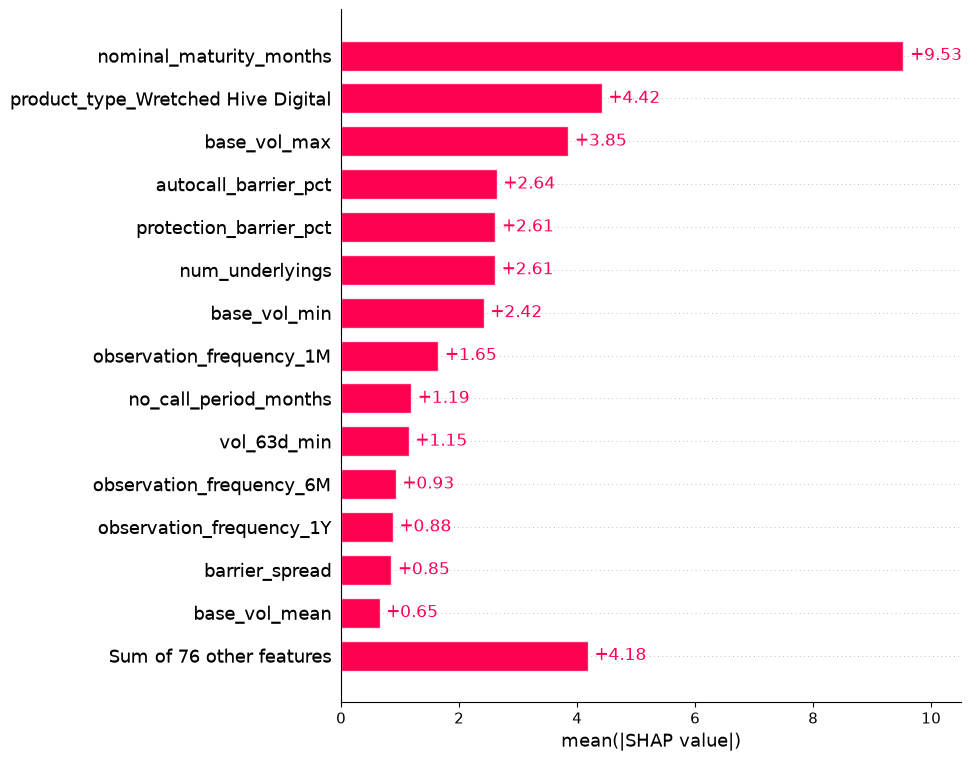

Impacto medio absoluto SHAP en variables foco:


,feature,mean_abs_shap
13,nominal_maturity_months,9.530123
0,autocall_barrier_pct,2.636806
1,protection_barrier_pct,2.613540
3,quoted_implied_vol,0.225950
15,vol_spread,0.210784


In [3]:
shap_model_name = 'XGBoost'
shap_model = xgboost_model

sample_size = min(1000, X_test.shape[0])
sample_idx = np.random.RandomState(42).choice(
    X_test.shape[0], sample_size, replace=False
)
X_shap = X_test.iloc[sample_idx]

try:
    explainer = shap.Explainer(shap_model, X_train)
    shap_values = explainer(X_shap)

    shap_importance = pd.DataFrame({
        'feature': X_train.columns,
        'mean_abs_shap': np.abs(shap_values.values).mean(axis=0)
    }).sort_values('mean_abs_shap', ascending=False)

    print(f'Modelo usado para SHAP: {shap_model_name}')
    print('Top 15 variables por impacto medio absoluto (SHAP):')
    display(shap_importance.head(15))

    shap.plots.bar(shap_values, max_display=15)
    plt.show()

    focus_vars = [
        'autocall_barrier_pct',
        'quoted_implied_vol',
        'vol_spread',
        'protection_barrier_pct',
        'nominal_maturity_months'
    ]

    print('Impacto medio absoluto SHAP en variables foco:')
    display(shap_importance[shap_importance['feature'].isin(focus_vars)])
except Exception as ex:
    print(f'No se pudo generar SHAP con {shap_model_name}: {ex}')

In [4]:
# Variables con menos impacto SHAP:
display(shap_importance.nsmallest(5, 'mean_abs_shap'))

,feature,mean_abs_shap
24,basket_type_worst_of,0.000000
21,product_type_Sith Eternal Snowball,0.000000
54,trader_id_TRD-004,0.000426
76,trader_id_TRD-026,0.000441
56,trader_id_TRD-006,0.000627


## Interpretación de resutados

La variable nominal_maturity_months es la que más peso tiene porque marca la duración máxima del contrato, estableciendo el techo temporal evidente ya que un producto diseñado a un año nunca podrá llegar a durar cinco. Le sigue muy de cerca autocall_barrier_pct, que funciona como la meta que deben superar los activos de la cesta para que el contrato se cancele antes de tiempo, de forma intuitiva, si esta barrera se pone muy alta, es mucho más difícil que las acciones la alcancen y por tanto el producto seguirá vivo durante más meses.  
Por el contrario, las variables con una importancia cercana a cero, como los identificadores de los traders o nombres de productos muy específicos como el Sith Eternal Snowball, apenas afectan a la predicción final, lo cual tiene sentido del negocio puesto que la duración de un derivado depende del comportamiento del mercado y de las reglas matemáticas del contrato, y no de qué empleado concreto del banco haya sido el encargado de tramitar la operación.